# Dataset Bayesian-optimization baseline

This first-pass inverse-design baseline searches **only existing rows** in the supplied structural dataset. It does not create a structural surrogate or run nTop/FEA. For each mission, it recomputes L/D with the supplied aerodynamic forward model, while mass, volume, and stress are read from the selected dataset row.

The optimizer uses a small NumPy Gaussian-process model of the official loss over the 21 design inputs. At iteration $i$, the probability of exploitation is $0.5 i/(N-1)$: it starts at 0% and rises linearly to 50%. An exploration step chooses an unseen dataset row uniformly; an exploitation step chooses the row with the lowest GP lower-confidence bound.

> **Important limitation.** Dataset rows include their own sampled flight condition. This is a valid row-retrieval baseline, but the structural labels are only approximate for a requested mission unless the row's flight condition is close to it. A next iteration should replace the direct row lookup with a structural surrogate conditioned on the requested flight condition.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import cho_factor, cho_solve

ROOT = Path.cwd()
if not (ROOT / 'data' / 'bwb_structures_dataset.csv').exists():
    raise FileNotFoundError('Run this notebook from the repository root.')
sys.path.insert(0, str(ROOT / 'models' / 'ld_surrogate'))
from predict_ld import predict_ld_batch

DATA_PATH = ROOT / 'data' / 'bwb_structures_dataset.csv'
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} dataset designs with {len(df.columns)} columns.')
df.head()

Loaded 13,720 dataset designs with 28 columns.


,C2/C1,C3/C1,C4/C1,B1/C1,B2/C1,B3/C1,X3/C1,S1,S3,C1,...,Rib Thickness,Wingbox Cutout,# of Fuselage Ribs,# of Fuselage Spars,Fuselage Struct Thickness,Fuselage Struct Width,Aircraft Empty Weight,Payload Volume,Fuel Volume,Max Hotspot Stress
0,0.608801,0.263608,0.082730,0.117657,0.066056,0.503989,0.619810,59.121322,32.081361,2936.196911,...,0.002263,0.019641,5,6,0.005910,0.003380,91.134825,296746703.0,8.292094e+07,173.490837
1,0.620455,0.231168,0.085050,0.127509,0.167601,0.635450,0.576304,43.038268,25.602682,2926.394255,...,0.001500,0.010000,3,3,0.002209,0.001272,45.538702,427223919.1,1.945945e+08,587.722663
2,0.735394,0.258656,0.078051,0.154553,0.194786,0.371031,0.602706,51.052789,38.364432,2547.896134,...,0.001500,0.010702,3,3,0.002033,0.001720,33.010278,386017482.2,1.991282e+08,392.003879
3,0.552518,0.241566,0.084456,0.183213,0.104000,0.389103,0.515766,44.081788,39.844212,3456.841378,...,0.001500,0.012997,3,3,0.002749,0.001684,78.741058,911105161.3,1.847925e+08,1227.035608
4,0.607566,0.205668,0.068895,0.138953,0.126264,0.568370,0.533624,56.522134,27.326020,3595.540248,...,0.001500,0.010000,3,3,0.002382,0.001446,75.769568,878491277.9,2.444846e+08,1809.479116


In [2]:
PLANFORM = ['C2/C1', 'C3/C1', 'C4/C1', 'B1/C1', 'B2/C1', 'B3/C1', 'X3/C1', 'S1', 'S3', 'C1']
STRUCTURE = ['Skin Thickness', 'Front Spar Chord %', 'Rear Spar Chord %', 'Spar Thickness',
             '# of Ribs', 'Rib Thickness', 'Wingbox Cutout', '# of Fuselage Ribs',
             '# of Fuselage Spars', 'Fuselage Struct Thickness', 'Fuselage Struct Width']
DESIGN_COLUMNS = PLANFORM + STRUCTURE
FLIGHT_COLUMNS = ['Altitude', 'KCAS', 'AOA']

MASS_REF_KG = 50.0
STRESS_LIMIT_MPA = 335.0
BUDGET = 100
RNG_SEED = 2026

TEST_CASES = [
    dict(name='High Speed Dash', ld_target=6.0, payload_volume_min_m3=0.75, fuel_volume_min_m3=0.45, altitude_kft=15.0, kcas_kt=120.0, aoa_deg=1.0),
    dict(name='Max Endurance', ld_target=10.0, payload_volume_min_m3=0.80, fuel_volume_min_m3=0.45, altitude_kft=15.0, kcas_kt=45.0, aoa_deg=8.0),
    dict(name='Max Capacity', ld_target=15.0, payload_volume_min_m3=1.00, fuel_volume_min_m3=0.65, altitude_kft=5.0, kcas_kt=220.0, aoa_deg=4.5),
]

def official_loss(metrics, mission):
    if metrics['stress_mpa'] > STRESS_LIMIT_MPA:
        return 1e6 + 1e3 * (metrics['stress_mpa'] - STRESS_LIMIT_MPA)
    return (0.4 * metrics['mass_kg'] / MASS_REF_KG
            + 0.2 * max(0.0, (mission['ld_target'] - metrics['ld']) / mission['ld_target'])
            + 0.2 * max(0.0, (mission['fuel_volume_min_m3'] - metrics['fuel_volume_m3']) / mission['fuel_volume_min_m3'])
            + 0.2 * max(0.0, (mission['payload_volume_min_m3'] - metrics['payload_volume_m3']) / mission['payload_volume_min_m3']))

def mission_metrics(frame, mission):
    ld = predict_ld_batch(frame, mission['altitude_kft'], mission['kcas_kt'], mission['aoa_deg'])
    return pd.DataFrame({
        'mass_kg': frame['Aircraft Empty Weight'].to_numpy(),
        'ld': ld,
        'payload_volume_m3': frame['Payload Volume'].to_numpy() / 1e9,
        'fuel_volume_m3': frame['Fuel Volume'].to_numpy() / 1e9,
        'stress_mpa': frame['Max Hotspot Stress'].to_numpy(),
    }, index=frame.index)

def loss_vector(metrics, mission):
    loss = (0.4 * metrics.mass_kg.to_numpy() / MASS_REF_KG
            + 0.2 * np.maximum(0, (mission['ld_target'] - metrics.ld.to_numpy()) / mission['ld_target'])
            + 0.2 * np.maximum(0, (mission['fuel_volume_min_m3'] - metrics.fuel_volume_m3.to_numpy()) / mission['fuel_volume_min_m3'])
            + 0.2 * np.maximum(0, (mission['payload_volume_min_m3'] - metrics.payload_volume_m3.to_numpy()) / mission['payload_volume_min_m3']))
    return np.where(metrics.stress_mpa.to_numpy() <= STRESS_LIMIT_MPA, loss, 1e6 + 1e3 * (metrics.stress_mpa.to_numpy() - STRESS_LIMIT_MPA))

In [3]:
def gp_lcb(X_train, y_train, X_query, noise=1e-6, length_scale=2.0, beta=1.5):
    """Fixed-hyperparameter RBF GP; returns a lower confidence bound for minimization."""
    y_mean, y_std = y_train.mean(), max(y_train.std(), 1e-8)
    y = (y_train - y_mean) / y_std
    def kernel(a, b):
        d2 = np.maximum(0.0, ((a[:, None, :] - b[None, :, :]) ** 2).sum(axis=2))
        return np.exp(-0.5 * d2 / length_scale**2)
    K = kernel(X_train, X_train) + noise * np.eye(len(X_train))
    factor = cho_factor(K, lower=True, check_finite=False)
    alpha = cho_solve(factor, y, check_finite=False)
    Ks = kernel(X_train, X_query)
    mean = Ks.T @ alpha
    v = cho_solve(factor, Ks, check_finite=False)
    variance = np.maximum(1e-10, 1.0 - np.sum(Ks * v, axis=0))
    return (mean - beta * np.sqrt(variance)) * y_std + y_mean

def search_dataset(mission, budget=BUDGET, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    metrics = mission_metrics(df, mission)
    losses = loss_vector(metrics, mission)
    X = df[DESIGN_COLUMNS].to_numpy(float)
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    available = np.ones(len(df), dtype=bool)
    chosen, chosen_loss, modes, exploit_schedule = [], [], [], []

    for i in range(budget):
        exploit_probability = 0.5 * i / (budget - 1)
        exploit_schedule.append(exploit_probability)
        use_exploit = i > 0 and rng.random() < exploit_probability
        pool = np.flatnonzero(available)
        if use_exploit:
            lcb = gp_lcb(X[np.array(chosen)], np.array(chosen_loss), X[pool])
            next_idx = pool[np.argmin(lcb)]
            modes.append('exploit')
        else:
            next_idx = rng.choice(pool)
            modes.append('explore')
        available[next_idx] = False
        chosen.append(next_idx)
        chosen_loss.append(losses[next_idx])

    history = pd.DataFrame({
        'iteration': np.arange(1, budget + 1), 'row_index': chosen, 'loss': chosen_loss,
        'incumbent_loss': np.minimum.accumulate(chosen_loss), 'mode': modes,
        'exploit_probability': exploit_schedule,
    })
    best_idx = chosen[int(np.argmin(chosen_loss))]
    return best_idx, metrics.loc[best_idx].to_dict(), history

# One representative run, used below to inspect the scheduled exploration/exploitation behavior.
best_idx, best_metrics, history = search_dataset(TEST_CASES[0])
print(f"Best row for {TEST_CASES[0]['name']}: {best_idx}; loss = {history.incumbent_loss.iloc[-1]:.4f}")

Best row for High Speed Dash: 1450; loss = 0.4352


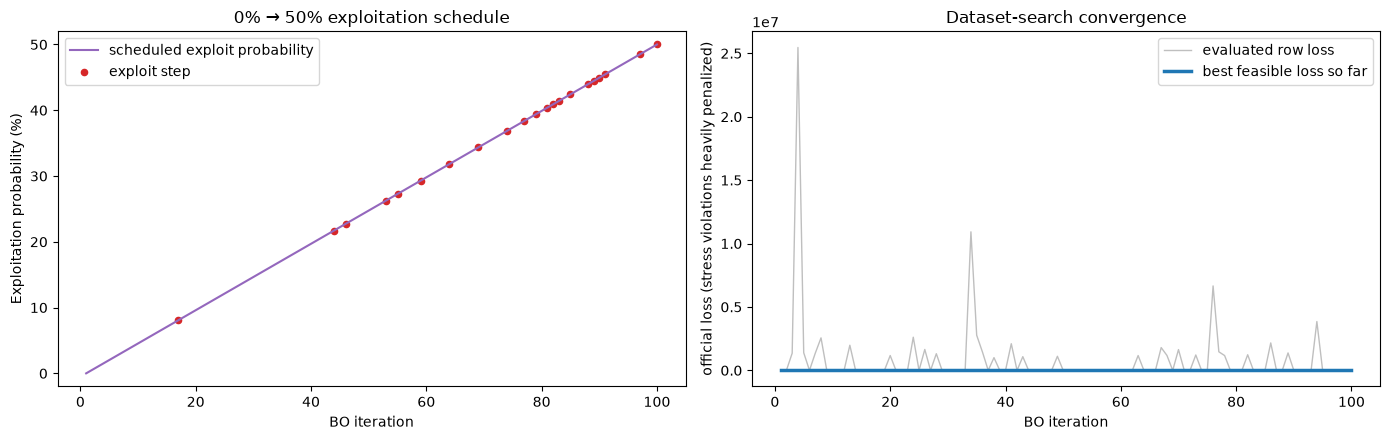

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(history.iteration, history.exploit_probability * 100, color='tab:purple', label='scheduled exploit probability')
exploit_steps = history['mode'].eq('exploit')
axes[0].scatter(history.loc[exploit_steps, 'iteration'], history.loc[exploit_steps, 'exploit_probability'] * 100,
                color='tab:red', s=20, label='exploit step')
axes[0].set(xlabel='BO iteration', ylabel='Exploitation probability (%)', ylim=(-2, 52), title='0% → 50% exploitation schedule')
axes[0].legend()

axes[1].plot(history.iteration, history.loss, color='0.75', lw=1, label='evaluated row loss')
axes[1].plot(history.iteration, history.incumbent_loss, color='tab:blue', lw=2.5, label='best feasible loss so far')
axes[1].set(xlabel='BO iteration', ylabel='official loss (stress violations heavily penalized)', title='Dataset-search convergence')
axes[1].legend()
fig.tight_layout()
plt.show()

,case,mission,dataset_row,loss,empty_mass_kg,ld,payload_volume_m3,fuel_volume_m3,max_hotspot_stress_mpa,stress_feasible,row_altitude_kft,row_kcas_kt,row_aoa_deg
0,1,High Speed Dash,7096,0.4895,37.2260,7.5806,0.4130,0.2209,186.7753,True,4.2146,115.3679,-7.3544
1,2,Max Endurance,2727,0.4928,26.7893,7.1119,0.4418,0.1549,326.1527,True,7.2478,95.9298,-0.1742
2,3,Max Capacity,3902,0.5451,34.1651,12.9606,0.4515,0.2116,211.9735,True,14.0777,62.8370,-0.2748


,case,mission,C2/C1,C3/C1,C4/C1,B1/C1,B2/C1,B3/C1,X3/C1,S1,...,Front Spar Chord %,Rear Spar Chord %,Spar Thickness,# of Ribs,Rib Thickness,Wingbox Cutout,# of Fuselage Ribs,# of Fuselage Spars,Fuselage Struct Thickness,Fuselage Struct Width
0,1,High Speed Dash,0.70013,0.27332,0.06910,0.13843,0.18076,0.47637,0.51691,42.41741,...,0.27524,0.64046,0.00150,7.0,0.0015,0.01000,3.0,3.0,0.00224,0.00187
1,2,Max Endurance,0.81495,0.22462,0.06855,0.16093,0.13218,0.61953,0.60722,47.60876,...,0.33648,0.61338,0.00122,5.0,0.0015,0.01081,3.0,3.0,0.00232,0.00122
2,3,Max Capacity,0.77778,0.20123,0.08529,0.15649,0.18666,0.54647,0.59689,49.94666,...,0.25411,0.55348,0.00141,5.0,0.0015,0.01097,3.0,3.0,0.00210,0.00140


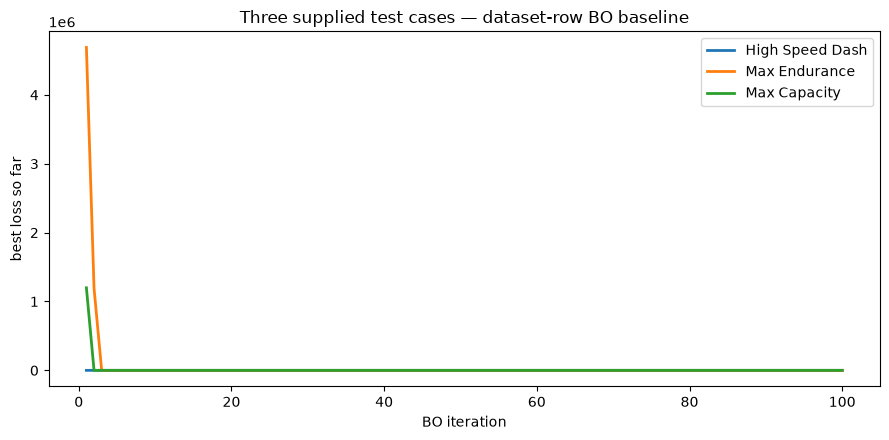

Rows are candidates from the supplied dataset. L/D is evaluated at the requested mission; structural labels remain row-evaluated values.


In [5]:
# Final block: run the same first-pass optimizer against all three README test cases.
records = []
designs = []
histories = {}
for case_number, mission in enumerate(TEST_CASES, start=1):
    idx, metrics, case_history = search_dataset(mission, seed=RNG_SEED + case_number)
    histories[mission['name']] = case_history
    row = df.loc[idx]
    records.append({
        'case': case_number, 'mission': mission['name'], 'dataset_row': idx,
        'loss': official_loss(metrics, mission), 'empty_mass_kg': metrics['mass_kg'], 'ld': metrics['ld'],
        'payload_volume_m3': metrics['payload_volume_m3'], 'fuel_volume_m3': metrics['fuel_volume_m3'],
        'max_hotspot_stress_mpa': metrics['stress_mpa'], 'stress_feasible': metrics['stress_mpa'] <= STRESS_LIMIT_MPA,
        'row_altitude_kft': row['Altitude'], 'row_kcas_kt': row['KCAS'], 'row_aoa_deg': row['AOA'],
    })
    designs.append({'case': case_number, 'mission': mission['name'], **row[DESIGN_COLUMNS].to_dict()})

summary = pd.DataFrame(records)
selected_designs = pd.DataFrame(designs)
display(summary.round(4))
display(selected_designs.round(5))

fig, ax = plt.subplots(figsize=(9, 4.5))
for name, case_history in histories.items():
    ax.plot(case_history.iteration, case_history.incumbent_loss, lw=2, label=name)
ax.set(xlabel='BO iteration', ylabel='best loss so far', title='Three supplied test cases — dataset-row BO baseline')
ax.legend()
fig.tight_layout()
plt.show()

print('Rows are candidates from the supplied dataset. L/D is evaluated at the requested mission; structural labels remain row-evaluated values.')